# From Co-pilot to Creator Following the AI-Driven Development Lifecycle Methodology

This lab guides you through the process of transforming a real-world business problem into a complete software solution using AI-assisted development. You'll start by defining a business challenge, then use a large language model (LLM) to generate key software development lifecycle (SDLC) artifacts; including problem statements, personas, requirements, user stories, API endpoints, and test scripts. 

The lab demonstrates how to leverage AI tools to accelerate and automate each step, resulting in a working FlaskAPI application with comprehensive test coverage.

## Setup & Environment
Prepare the Python environment, import required libraries, and initialize the LLM client. This ensures reproducibility.

In [1]:
import os
import sys
# Add the parent directory to sys.path so we can import the 'utils' module
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

# Import all needed utilities at once
from utils import (
    load_environment,
    get_completion,
    setup_llm_client,
    clean_llm_output,
    recommended_models_table,
)

# Ensure Pillow (used for diagram rendering) is installed
try:
    from PIL import Image  # noqa: F401
    print("✅ Pillow already installed")
except ImportError:
    print("Installing Pillow...")
    %pip install pillow
    from PIL import Image  # re-import after installation

# Load environment variables (e.g., API keys from .env file)
load_environment()

# Initialize the LLM client – model can be configured via environment variable
MODEL_NAME = os.getenv("LLM_MODEL", "openai/gpt-5.2")

try:
    client, model_name, api_provider = setup_llm_client(MODEL_NAME)
    print(f"✅ LLM Client initialized: {api_provider} - {model_name}")
except Exception as e:
    print(f"❌ Error initializing LLM client: {e}")
    raise   # Stop execution if the LLM client cannot be created

✅ Pillow already installed
✅ LLM Client configured: Using 'apifree' with model 'openai/gpt-5.2'
✅ LLM Client initialized: apifree - openai/gpt-5.2


# Phase 1: Inception
Inception is the phase where business intent is converted into execution-ready context. This phase focuses on capturing Intents and translating them into Units for development.

An Intent is a high-level statement of purpose that encapsulates what needs to be achieved, serving as a starting point for the methodology. In this practical, we will be driven by the (1) business problem, (2) personas, (3) requirements, and (4) user stories.

In [2]:
business_problem = """
Build a Freudian dream interpretation website with the following workflow:

1. A user submits a detailed dream description (free text).
2. The system generates exactly 5–7 open-ended follow‑up questions based on Freudian theory.
   These questions should probe symbols, repressed desires, childhood memories, and emotional conflicts.
3. The user answers all questions in a guided form.
4. The system then produces:
   - A full dream interpretation (manifest vs latent content, wish fulfillment, etc.)
   - An assessment of the user's current psychological state, highlighting possible unconscious conflicts.
   - Personalized mental well‑being suggestions.
5. All dream data (description, questions, answers, analysis) are stored per user session
   and can be reviewed later.

The interface should guide the user through these steps in a smooth, step-by-step manner
(e.g., a single-page application with progressive disclosure).
The tone must feel therapeutic, professional, and use appropriate Freudian vocabulary.
"""

#### 1) AI generated –Business problem

In [4]:
if client and 'business_problem' in globals():
    print("--- Generating Problem Statement ---")
    prompt = (
        "Read the business problem below and produce a single, concise problem statement.\n"
        "The statement MUST start with 'Design and develop a website that...' and explicitly mention:\n"
        "- Freudian dream interpretation\n"
        "- Multi-step interaction (dream input → follow-up questions → analysis)\n"
        "- Storage of user sessions for later review\n\n"
        f"Business Problem:\n{business_problem}"
    )
    problem_statement = get_completion(
        prompt, client, model_name, api_provider, temperature=0.2
    )
    print(problem_statement)
else:
    print("Skipping step because LLM client or business problem is not available.")

--- Generating Problem Statement ---
Design and develop a website that provides Freudian dream interpretation through a multi-step interaction (dream input → follow-up questions → analysis), generating 5–7 open-ended Freudian follow-up questions, producing a therapeutic-professional interpretation and well-being suggestions, and storing complete user sessions (dream, questions, answers, analysis) for later review.


#### 2) AI generated –Personas (as in the Agile methodology)

In [5]:
if client and 'problem_statement' in globals():
    print("--- Generating Personas ---")
    prompt = (
           "Generate exactly 3 user personas for a Freudian dream interpretation website. "
        "Use the format below exactly:\n\n"
        "Personas: <one-sentence intro>\n\n"
        "1. **Role Title**\n   - **Responsibilities:** ...\n   - **Needs:** ...\n\n"
        "2. **Role Title**\n   - **Responsibilities:** ...\n   - **Needs:** ...\n\n"
        "3. **Role Title**\n   - **Responsibilities:** ...\n   - **Needs:** ...\n\n"
        "Rules:\n"
        "- Use single role titles only; no slashes (/) or combined titles.\n"
        "- Keep each bullet concise (1-2 sentences).\n"
        "- The three roles must be: Dreamer, Freudian AI Analyst, and Administrator.\n"
        "- Incorporate Freudian terminology (e.g., latent content, wish fulfillment, unconscious conflict) in the descriptions.\n"
        "- The Dreamer needs a safe, therapeutic experience; the AI Analyst needs to probe deeply using psychoanalytic principles; "
        "the Administrator needs data management and compliance tools.\n\n"
        f"Problem Statement: {problem_statement}"
    )
    personas = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    print(f"Personas: {personas}")
else:
    print("Skipping step because LLM client or problem statement is not available.")

--- Generating Personas ---
Personas: Personas: Three key users collaborate to deliver a multi-step Freudian dream interpretation flow from dream input to stored session review.

1. **Dreamer**
   - **Responsibilities:** Shares dream narratives, answers 5–7 open-ended follow-up questions, and reflects on possible latent content and unconscious conflict. Reviews interpretations and well-being suggestions over time.
   - **Needs:** A safe, therapeutic-professional experience with clear boundaries, privacy controls, and compassionate language while exploring wish fulfillment and sensitive material.

2. **Freudian AI Analyst**
   - **Responsibilities:** Generates 5–7 open-ended psychoanalytic follow-up questions to elicit latent content, resistance, and possible wish fulfillment. Produces a structured interpretation and well-being suggestions grounded in unconscious conflict and symbolism.
   - **Needs:** Tools to probe deeply using Freudian principles (e.g., manifest vs. latent content, c

#### 3) AI generated –Requirements based on the problem statement and personas

In [6]:
if client and 'problem_statement' in globals() and 'personas' in globals():
    print("--- Generating PRD ---")
    prompt = (
    
    "Write a comprehensive Product Requirements Document (PRD) in markdown. "
    "You MUST use exactly the following headings, each with 2-4 concise bullets:\n"
    "## Overview\n## Goals\n## Non-Goals\n## User Personas (brief)\n"
    "## Key Features\n## User Flows\n## Functional Requirements\n"
    "## Non-Functional Requirements\n## Constraints/Assumptions\n"
    "## Success Metrics\n## Open Questions\n\n"
    "Rules:\n"
    "- Use ONLY the headings listed above. No extra sections.\n"
    "- Keep each bullet to one or two sentences.\n"
    "- The PRD must describe a Freudian dream interpretation website.\n"
    "- Incorporate the following domain-specific details where relevant:\n"
    "  * Multi-step workflow: dream input → follow-up questions → analysis.\n"
    "  * Freudian concepts: latent content, wish fulfillment, free association.\n"
    "  * Data storage: user sessions that save dream, questions, answers, and analysis.\n"
    "  * Theraputic and professional tone in user-facing language.\n"
    f"Problem Statement: {problem_statement}\n"
    f"Personas: {personas}"

    )
    prd = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3,
    )
    prd = clean_llm_output(prd, language='markdown')
    print(f"PRD: {prd}")
    # Ensure artifacts directory exists
    os.makedirs('artifacts', exist_ok=True)
    # Save PRD as Markdown
    with open('artifacts/prd.md', 'w') as f:
        f.write(prd)
    print('✅ Saved: artifacts/prd.md')
else:
    print("Skipping step because LLM client, problem statement, or personas are not available.")

--- Generating PRD ---
PRD: ## Overview
- Build a Freudian dream interpretation website with a guided, multi-step workflow: dream input → 5–7 open-ended follow-up questions → analysis.
- Provide therapeutic-professional, non-judgmental language that explores manifest vs. latent content, wish fulfillment, and free association.
- Store complete user sessions (dream, questions, answers, analysis) for later review with clear privacy controls and boundaries.
- Support administrators in managing accounts, retention, and content safety for sensitive narratives.

## Goals
- Help Dreamers reflect on potential latent content and unconscious conflict using structured Freudian prompts and free-association cues.
- Generate a coherent interpretation that explicitly distinguishes manifest content from hypothesized latent themes and wish fulfillment.
- Deliver practical well-being suggestions framed as supportive reflections rather than clinical diagnosis or treatment.
- Enable reliable session saving

#### 4) AI generated –User stories from the PRD and personas

In [7]:
if client and 'prd' in globals():
    print("--- Generating User Stories ---")
    prompt = (
       "Return ONLY valid JSON with this schema:\n"
"{\n  \"user_stories\": [\n    {\n      \"id\": 1,\n      \"role\": \"<role>\",\n"
"      \"goal\": \"<goal>\",\n      \"benefit\": \"<benefit>\",\n"
"      \"acceptance_criteria\": [\"<criteria>\", \"<criteria>\"]\n    }\n  ]\n}\n\n"
"Rules:\n"
"- Provide exactly 6 user stories.\n"
"- Stories must cover the full multi-step Freudian dream interpretation workflow:\n"
"  1) Dream submission, 2) Generating follow‑up questions, 3) Answering questions,\n"
"  4) Receiving full analysis (interpretation, psychological assessment, suggestions),\n"
"  5) Reviewing past dream sessions, 6) Administration and session management.\n"
"- Use only the three personas from the PRD (Dreamer, Freudian AI Analyst, Administrator).\n"
"- Incorporate Freudian vocabulary where appropriate (manifest/latent content, wish fulfillment, etc.).\n"
"- Keep each field concise. No extra keys.\n"
f"PRD: {prd}"
    )
    user_stories = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    user_stories = clean_llm_output(user_stories, language='json')
    print(f"User Stories: {user_stories}")
    # Save user stories as JSON
    import json, os
    os.makedirs('artifacts', exist_ok=True)
    user_stories_data = { 'user_stories': user_stories }
    with open('artifacts/user_stories.json', 'w') as f:
        json.dump(user_stories_data, f, indent=2)
    print('✅ Saved: artifacts/user_stories.json')
else:
    print("Skipping step because LLM client or PRD is not available.")

--- Generating User Stories ---
User Stories: {
  "user_stories": [
    {
      "id": 1,
      "role": "Dreamer",
      "goal": "submit the manifest dream narrative, emotions, and immediate associations in a guided form",
      "benefit": "so my session can be saved and used for later latent-content exploration",
      "acceptance_criteria": [
        "Form captures dream text, emotions, and initial free associations",
        "Session is saved as a draft and can be resumed after refresh or device change"
      ]
    },
    {
      "id": 2,
      "role": "Freudian AI Analyst",
      "goal": "generate 5–7 open-ended follow-up questions grounded in free association and Freudian concepts",
      "benefit": "so the Dreamer can explore possible condensation, displacement, resistance, and wish fulfillment",
      "acceptance_criteria": [
        "Produces exactly 5–7 questions tailored to the submitted manifest content",
        "Questions avoid leading claims and use therapeutic-professiona

## Phase 2: Construction
Construction is the phase where AI plans and builds the system end-to-end using the established context, with humans validating outcomes. In this practical, we focus on (1) UML diagrams followed by the (2) product code.

#### 1) AI generated –UML diagrams

--- Generating PlantUML Use Case Diagram ---
Generated PlantUML diagram:
@startuml
actor Dreamer
actor "Freudian AI Analyst" as FreudianAIAnalyst
actor Administrator

rectangle "Dream Analysis System" {
  usecase "Submit dream narrative" as SubmitDream
  usecase "Generate follow-up questions" as GenerateQuestions
  usecase "Answer follow-up questions" as AnswerQuestions
  usecase "Produce structured analysis" as ProduceAnalysis
  usecase "Review dream sessions" as ReviewSessions
  usecase "Export session" as ExportSession
  usecase "Delete session" as DeleteSession
  usecase "Manage accounts and retention" as ManageAccountsRetention
  usecase "Apply retention rules" as ApplyRetentionRules
  usecase "Process export requests" as ProcessExportRequests
  usecase "Process delete requests" as ProcessDeleteRequests
  usecase "Provide safety boundary language" as SafetyBoundaryLanguage
}

Dreamer -- SubmitDream
FreudianAIAnalyst -- GenerateQuestions
Dreamer -- AnswerQuestions
FreudianAIAnalyst

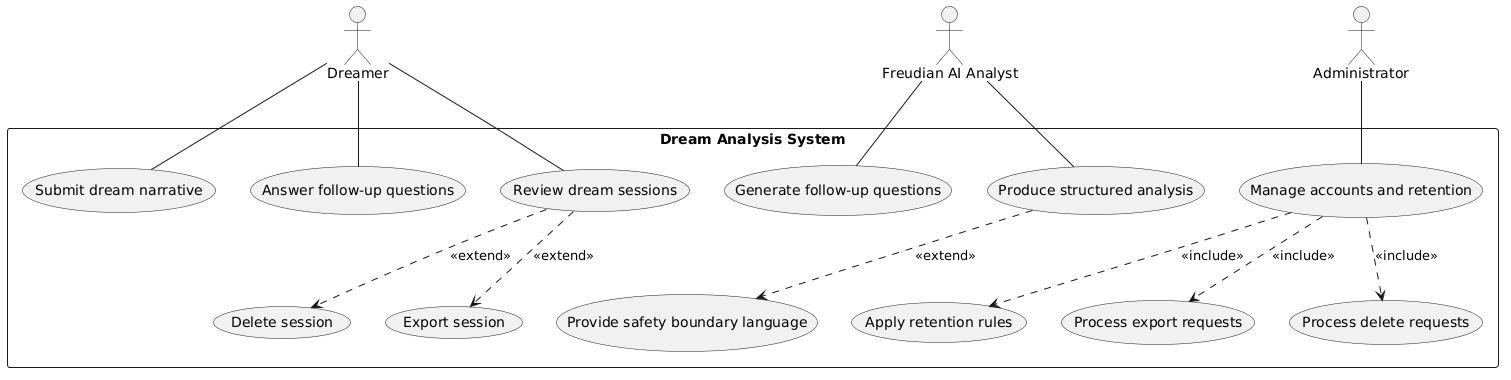

In [8]:
from utils import render_plantuml_diagram

if client and 'user_stories' in globals():
    print("--- Generating PlantUML Use Case Diagram ---")
    prompt = (
        "Generate a UML-compliant PlantUML use case diagram based on the user stories below.\n"
        "Use standard UML notation and PlantUML syntax.\n\n"
        "Required structure:\n"
        "@startuml\n"
        "actor ActorName\n"
        "actor AnotherActor\n\n"
        "rectangle \"System\" {\n"
        "  usecase \"Use Case Name\" as UC1\n"
        "  usecase \"Another Use Case\" as UC2\n"
        "}\n\n"
        "ActorName -- UC1\n"
        "AnotherActor -- UC2\n"
        "@enduml\n\n"
        "UML Rules:\n"
        "- Actors must be defined using the `actor` keyword and placed outside the system boundary\n"
        "- The system boundary must be a `rectangle` with a meaningful system name (default: \"System\")\n"
        "- Use cases must be defined using the `usecase` keyword and placed inside the system boundary\n"
        "- Associations between actors and use cases must use `--` (undirected association), not arrows\n"
        "- Do NOT number use case names; use clear verb–noun phrases instead\n"
        "- Extract unique actors from the `role` field in the user stories\n"
        "- Create one use case per distinct `goal` field\n"
        "- Keep use case names concise (max 5 words)\n"
        "- If a user story implies reuse, model it with `<<include>>`\n"
        "- If a user story implies optional or conditional behavior, model it with `<<extend>>`\n"
        "- Avoid layout directives unless necessary\n"
        "- Return ONLY valid PlantUML code, with no explanations or commentary\n\n"
        f"User Stories: {user_stories}"
    )

    puml = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    puml = clean_llm_output(puml, language='text')
    print("Generated PlantUML diagram:")
    print(puml)
    
    # Save to file
    os.makedirs('artifacts/diagrams', exist_ok=True)
    with open('artifacts/diagrams/use_case_diagram.puml', 'w') as f:
        f.write(puml)
    print('✅ Saved: artifacts/diagrams/use_case_diagram.puml')
    render_plantuml_diagram(puml, "artifacts/diagrams/use_case_diagram.png")
else:
    print("Skipping step because LLM client or user_stories is not available.")



In [11]:
from utils import render_plantuml_diagram
import os

if client and 'user_stories' in globals():
    print("--- Generating PlantUML Use Case Diagram ---")
    prompt = (
        "Generate a UML-compliant PlantUML use case diagram based on the user stories below.\n"
        "Use standard UML notation and PlantUML syntax.\n\n"
        "Required structure:\n"
        "@startuml\n"
        "actor ActorName\n"
        "actor AnotherActor\n\n"
        "rectangle \"Freudian Dream Interpretation System\" {\n"
        "  usecase \"Use Case Name\" as UC1\n"
        "  usecase \"Another Use Case\" as UC2\n"
        "}\n\n"
        "ActorName -- UC1\n"
        "AnotherActor -- UC2\n"
        "@enduml\n\n"
        "UML Rules:\n"
        "- Actors must be defined using the `actor` keyword and placed outside the system boundary.\n"
        "- The system boundary must be a `rectangle` with the name: \"Freudian Dream Interpretation System\".\n"
        "- Use cases must be defined using the `usecase` keyword and placed inside the system boundary.\n"
        "- Associations between actors and use cases must use `--` (undirected association), not arrows.\n"
        "- Do NOT number use case names; use clear verb–noun phrases instead.\n"
        "- Extract unique actors from the `role` field in the user stories.\n"
        "- Create one use case per distinct `goal` field.\n"
        "- Keep use case names concise (max 5 words).\n"
        "- IMPORTANT: Model relationships based on the acceptance criteria:\n"
        "  * If a use case always involves another step (e.g., answering questions always triggers analysis), use `<<include>>` from the base use case to the included one.\n"
        "  * If a use case is optional or conditional (e.g., reviewing history, admin features), use `<<extend>>` from the base use case.\n"
        "  * For multi-step workflows like \"Submit Dream → Generate Questions → Answer Questions → View Analysis\", chain them with `<<include>>` relationships where appropriate.\n"
        "- Avoid layout directives unless necessary.\n"
        "- Return ONLY valid PlantUML code, with no explanations or commentary.\n\n"
        f"User Stories: {user_stories}"
    )

    puml = get_completion(
        prompt, client, model_name, api_provider, temperature=0.4  # 稍高温度，增强关系推理
    )
    puml = clean_llm_output(puml, language='text')
    
    # 简单校验：必须包含 @startuml 和 @enduml
    if '@startuml' not in puml or '@enduml' not in puml:
        print("⚠️ Generated PlantUML seems incomplete. Consider regenerating.")
        print(puml)
    else:
        print("✅ PlantUML generated successfully.")
        print(puml)
    
    # 保存文件
    os.makedirs('artifacts/diagrams', exist_ok=True)
    with open('artifacts/diagrams/use_case_diagram.puml', 'w') as f:
        f.write(puml)
    print('✅ Saved: artifacts/diagrams/use_case_diagram.puml')
    
    # 渲染图片
    try:
        render_plantuml_diagram(puml, "artifacts/diagrams/use_case_diagram.png")
        print("✅ Diagram rendered and saved to: artifacts/diagrams/use_case_diagram.png")
    except Exception as e:
        print(f"⚠️ Rendering failed: {e}")
else:
    print("Skipping step because LLM client or user_stories is not available.")
  puml = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    puml = clean_llm_output(puml, language='text')
    print("Generated PlantUML diagram:")
    print(puml)
    
    # Save to file
    os.makedirs('artifacts/diagrams', exist_ok=True)
    with open('artifacts/diagrams/use_case_diagram.puml', 'w') as f:
        f.write(puml)
    print('✅ Saved: artifacts/diagrams/use_case_diagram.puml')
    render_plantuml_diagram(puml, "artifacts/diagrams/use_case_diagram.png")
else:
    print("Skipping step because LLM client or user_stories is not available.")

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 65)

#### 2) AI generated Code

In [ ]:
if client and 'user_stories' in globals():
    import json
    print("--- Generating Flask API App Code & Complementary Frontend ---")
    
    # Parse user stories
    try:
        stories_data = json.loads(user_stories) if isinstance(user_stories, str) else user_stories
        stories_list = stories_data if isinstance(stories_data, list) else stories_data.get('user_stories', [])
    except:
        print("Error parsing user stories")
        stories_list = []
    
    # Generate base app structure first
    base_app = get_completion(
        "Create a minimal Flask app skeleton with: from flask import Flask, request, jsonify, send_from_directory; app = Flask(__name__); in-memory storage using feedback_db = []; Add CORS support with from flask_cors import CORS; CORS(app); Add a health check endpoint GET /health that returns {status: ok}. Keep it under 20 lines.",
        client, model_name, api_provider, temperature=0.3
    )
    base_app = clean_llm_output(base_app, language='python')
    
    print(f"✅ Generated base app structure")
    
    # Generate endpoints for each user story iteratively
    endpoints_code = []
    for i, story in enumerate(stories_list[:3], 1):  # Limit to first 3 stories to keep it manageable
        story_text = f"Role: {story.get('role', '')}, Goal: {story.get('goal', '')}"
        print(f"  Generating endpoint {i}/3 for: {story.get('role', 'user')[:30]}...")
        
        endpoint_code = get_completion(
            f"Write 1-2 Flask endpoint functions for this user story: {story_text}. Use feedback_db list for storage. Return only the function code (e.g., @app.route decorated functions), no imports or app initialization. Keep under 25 lines. Ensure endpoints return JSON with proper status codes.",
            client, model_name, api_provider, temperature=0.3
        )
        endpoint_code = clean_llm_output(endpoint_code, language='python')
        endpoints_code.append(f"\n# Endpoint for Story {i}: {story.get('role', 'user')}\n{endpoint_code}")
    
    # Add a catch-all route to serve index.html
    frontend_route = """
# Serve frontend
@app.route('/')
def index():
    return send_from_directory('.', 'index.html')

@app.route('/<path:filename>')
def serve_static(filename):
    return send_from_directory('.', filename)
"""
    
    # Combine all code with Docker-compatible host binding
    main_py_code = base_app + "\n".join(endpoints_code) + frontend_route
    main_py_code += "\n\nif __name__ == '__main__':\n    # Bind to 0.0.0.0 to make it accessible from Docker\n    app.run(host='0.0.0.0', debug=True, port=5005)"
    
    os.makedirs('artifacts/app/flask', exist_ok=True)
    with open('artifacts/app/flask/main.py', 'w') as f:
        f.write(main_py_code)
    print('✅ Saved: artifacts/app/flask/main.py')
    
    # Extract endpoint routes for frontend integration
    import re
    route_pattern = r"@app\.route\(['\"]([^'\"]+)['\"](?:,\s*methods=\[([^\]]+)\])?\)"
    routes = re.findall(route_pattern, main_py_code)
    routes_text = ', '.join([f"{route} ({methods if methods else 'GET'})" for route, methods in routes])
    
    print(f"  Available API endpoints: {routes_text}")
    
    # Generate complementary HTML frontend that integrates with the API
    html_prompt = (
        "Generate a complete, production-ready HTML5 webpage that serves as a feedback collection system. "
        "Requirements: "
        "(1) Use Bootstrap 5 CSS framework via CDN for professional styling. "
        "(2) Include a form with input fields for: user name (text), email address (email), feedback message (textarea), and rating (select 1-5). "
        "(3) Add a Submit button that sends form data via POST request to http://127.0.0.1:5005/feedback as JSON. "
        "(4) Add a section that fetches and displays all existing feedback from http://127.0.0.1:5005/feedback using GET request. "
        "(5) Display feedback in a card or list format with name, rating, and message visible. "
        "(6) Include client-side form validation (all fields required). "
        "(7) Show success/error messages after form submission using alerts. "
        "(8) Handle network errors gracefully with user-friendly error messages. "
        "(9) Include all CSS styling inline in <style> tags. "
        "(10) Include all JavaScript logic inline in <script> tags. "
        "(11) Use Fetch API for all HTTP requests. "
        "Output ONLY the complete, valid HTML document. No explanations or markdown."
    )
    
    html_code = get_completion(
        html_prompt, client, model_name, api_provider, temperature=0.4
    )
    html_code = clean_llm_output(html_code, language='html')
    
    # Save HTML file
    with open('artifacts/app/flask/index.html', 'w') as f:
        f.write(html_code)
    print('✅ Saved: artifacts/app/flask/index.html')
    
    # Generate README.md with integration instructions
    readme_content = get_completion(
        "Write a README.md (under 250 words) for an integrated Flask feedback API with HTML frontend. Include: title, description, setup (pip install flask flask-cors), run command (python main.py), how to access the app (http://127.0.0.1:5005), and 2 curl examples for POST /feedback and GET /feedback endpoints. Also mention the interactive HTML frontend is served automatically.",
        client, model_name, api_provider, temperature=0.3
    )
    with open('artifacts/app/flask/README.md', 'w') as f:
        f.write(readme_content)
    print('✅ Saved: artifacts/app/flask/README.md')
    print("\n✅ API and Frontend code generated and saved successfully!")
else:
    print("Skipping step because LLM client or user_stories is not available.")

In [ ]:
if client and os.path.exists('artifacts/app/flask/main.py'):
    print("--- Generating requirements.txt ---")
    
    # Read the app code
    with open('artifacts/app/flask/main.py', 'r') as f:
        app_code = f.read()
    
    # Extract only import statements from the beginning of the file
    import_lines = []
    for line in app_code.split('\n'):
        stripped = line.strip()
        if stripped.startswith('import ') or stripped.startswith('from '):
            import_lines.append(stripped)
        elif stripped and not stripped.startswith('#'):
            # Stop at first non-import, non-comment line
            break
    
    imports_text = '\n'.join(import_lines)
    print(f"  Found {len(import_lines)} import statement(s)")
    
    # Generate requirements based on imports only
    requirements = get_completion(
        f"Based on these Python import statements, list all required package dependencies (one per line). Include only package names, no version constraints. Remove duplicates and standard library. Import statements:\n{imports_text}",
        client, model_name, api_provider, temperature=0.3
    )
    requirements = clean_llm_output(requirements, language='text')
    
    # Parse and clean requirements
    req_lines = [line.strip() for line in requirements.split('\n')]
    req_lines = [line for line in req_lines if line and not line.startswith('#')]  # Remove empty lines and comments
    req_set = set(req_lines)  # Remove duplicates
    req_list = sorted(list(req_set))  # Sort for consistency
    
    # Reconstruct clean requirements
    clean_requirements = '\n'.join(req_list)
    
    with open('artifacts/app/flask/requirements.txt', 'w') as f:
        f.write(clean_requirements)
    print(f'✅ Saved: artifacts/app/flask/requirements.txt ({len(req_list)} packages)')
    print(f"  Packages: {', '.join(req_list)}")
else:
    print("Skipping step because Flask app is not available.")

## Phase 3: Operation
AI oversees deployments, infrastructure-as-code, monitoring, and ongoing operations based on the accumulated project context. The team continues oversight and governance.

As for this practical and due to the scope of the lab, we will limit to package the application into a Docker container for easy deployment and reproducibility.

In [ ]:
import os

# Generate Dockerfile for the Flask application
dockerfile_content = """FROM python:3.11-slim

# Set working directory
WORKDIR /app

# Copy requirements and install dependencies
COPY flask/requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy application files
COPY flask/ .

# Expose port
EXPOSE 5005

# Set environment variables
ENV FLASK_APP=main.py
ENV FLASK_ENV=production

# Run the application
CMD ["python", "main.py"]
"""

# Generate .dockerignore file
dockerignore_content = """__pycache__
*.pyc
*.pyo
*.pyd
.Python
env/
venv/
.venv
.git
.gitignore
.env
.DS_Store
*.egg-info
dist
build
.pytest_cache
"""

# Generate docker-compose.yml for orchestration
docker_compose_content = """version: '3.8'

services:
  flask-app:
    build:
      context: .
      dockerfile: docker/Dockerfile
    container_name: feedback-app
    ports:
      - "5005:5005"
    environment:
      - FLASK_ENV=production
      - FLASK_APP=main.py
    volumes:
      - ./flask:/app
    restart: unless-stopped
"""

# Create Docker configuration files
if os.path.exists('artifacts/app/flask/main.py'):
    print("--- Generating Docker Configuration Files ---")
    
    # Ensure docker directory exists
    os.makedirs('artifacts/app/docker', exist_ok=True)
    
    # Save Dockerfile
    with open('artifacts/app/docker/Dockerfile', 'w') as f:
        f.write(dockerfile_content)
    print('✅ Saved: artifacts/app/docker/Dockerfile')
    
    # Save .dockerignore
    with open('artifacts/app/docker/.dockerignore', 'w') as f:
        f.write(dockerignore_content)
    print('✅ Saved: artifacts/app/docker/.dockerignore')
    
    # Save docker-compose.yml in artifacts/app
    with open('artifacts/app/docker-compose.yml', 'w') as f:
        f.write(docker_compose_content)
    print('✅ Saved: artifacts/app/docker-compose.yml')
    
    print("\n--- Docker Build & Run Instructions ---")
    print("""
📦 To build and run the Docker container:

IMPORTANT: All commands must be run from the artifacts/app directory!

1. Navigate to the app directory:
   cd artifacts/app

2. Build the Docker image:
   docker build -t feedback-app:latest -f docker/Dockerfile .

3. Run the container:
   docker run -p 5005:5005 feedback-app:latest

4. Alternative: Use Docker Compose (recommended):
   docker-compose up --build

5. Access the application:
   Open http://127.0.0.1:5005 in your browser

6. View logs:
   docker logs -f feedback-app

7. Stop the container:
   docker stop feedback-app
   
8. Clean up:
   docker-compose down
    """)
    
    print("\n✅ Docker containerization setup complete!")
else:
    print("❌ Flask app not found. Please run the code generation cell first.")